# <a id='toc1_'></a>[Plot the best and worst-performing municipalities for global models](#toc0_)

This notebook loads NRMSE data to find the best and worst-performing municipalities for the global models (considering their best-performing model type) and plotting their complete time series, including conformal prediction 95% confidence intervals.

**Table of contents**<a id='toc0_'></a>    
- [Plot the best and worst-performing municipalities for global models](#toc1_)    
- [Best-performing municipalities](#toc2_)    
- [Worst-performing municipalities](#toc3_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.transforms as transforms
import sys
from pathlib import Path

sys.path.append('../models')

from model_rr import Model

In [2]:
cantons = [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 201, -202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 301, 302, 303, 304, 305, 306, 307, 308, 401, 402, 403, 404, 405, 406, 407, 408, 409, 410, 501, 502, 503, 504, 505, 506, 507, 508, 509, 510, 511, 601, 602, 603, 604, 605, 606, 607, 608, 609, 610, 611, 701, 702, 703, 704, 705, 706]

cantons = [str(x) for x in cantons]

In [4]:
df = pd.read_csv('../full_data.csv')

In [5]:
df_nrmse = pd.read_csv(f"../data/model_results/metrics/best_model_full_confint_test.csv")

In [6]:
df_nrmse["lowest_nrmse"] = df_nrmse.loc[:, ['nrmse_rf', 'nrmse_xgb', 'nrmse_hrf', 'nrmse_hxgb']].min(axis=1)

# <a id='toc2_'></a>[Best-performing municipalities](#toc0_)

In [6]:
best_cantons = df_nrmse.nsmallest(6, "lowest_nrmse").iloc[:, 0].tolist()
best_cantons

[117, 101, 201, 601, 110, 109]

In [ ]:
df_nrmse # Print dataframe to check the values of lowest_nrmse and the best-performing model type. We do the same for the worst-performing cantons.

,canton,nrmse_rf,mean_rf,lower_rf,upper_rf,nrmse_xgb,mean_xgb,lower_xgb,upper_xgb,nrmse_hrf,...,upper_hrf,nrmse_hxgb,mean_hxgb,lower_hxgb,upper_hxgb,best_nrmse_model,best_mean_model,best_lower_model,best_upper_model,lowest_nrmse
0,101,0.330563,0.329503,0.260636,0.402450,0.348908,0.346972,0.294245,0.398357,0.275804,...,0.328865,0.301547,0.299223,0.238515,0.356827,nrmse_hrf,mean_hrf,lower_hrf,upper_hrf,0.275804
1,102,1.162495,1.151686,0.951745,1.319656,1.138141,1.131237,0.952410,1.285742,1.281000,...,1.642297,1.243749,1.245068,0.980185,1.531365,nrmse_xgb,mean_xgb,lower_rf,upper_xgb,1.138141
2,103,0.727550,0.713189,0.553415,0.867016,0.733218,0.719769,0.560442,0.861503,0.717977,...,0.911597,0.708387,0.707112,0.564788,0.884836,nrmse_hxgb,mean_hxgb,lower_rf,upper_xgb,0.708387
3,104,1.599182,1.582620,1.368483,1.848644,1.604487,1.585048,1.364691,1.817340,2.187357,...,3.186964,2.079355,2.121954,1.645601,2.860212,nrmse_rf,mean_rf,lower_xgb,upper_xgb,1.599182
4,105,2.230510,2.095969,1.044624,2.350112,2.230239,2.025678,0.417229,2.373252,2.705636,...,4.339687,2.636009,2.521311,1.017324,3.884538,nrmse_xgb,mean_xgb,lower_xgb,upper_rf,2.230239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,702,0.830942,0.817404,0.682160,0.960381,0.832133,0.823851,0.692888,0.967114,1.017273,...,1.390199,0.988234,0.987768,0.745699,1.276161,nrmse_rf,mean_rf,lower_rf,upper_rf,0.830942
78,703,0.758357,0.757283,0.601956,0.949565,0.770505,0.765225,0.600200,0.955178,1.160532,...,1.660042,1.012889,1.013135,0.726910,1.389744,nrmse_rf,mean_rf,lower_xgb,upper_rf,0.758357
79,704,1.123944,1.119810,0.945690,1.336214,1.113208,1.107995,0.940960,1.299329,1.141601,...,1.544978,1.226068,1.232444,0.932784,1.561040,nrmse_xgb,mean_xgb,lower_hrf,upper_xgb,1.113208
80,705,1.319359,1.302704,1.073079,1.527037,1.313240,1.296842,1.061752,1.548839,1.581424,...,2.203816,1.880275,1.902213,1.374443,2.661553,nrmse_xgb,mean_xgb,lower_xgb,upper_rf,1.313240


Elapsed time: 212.65 seconds


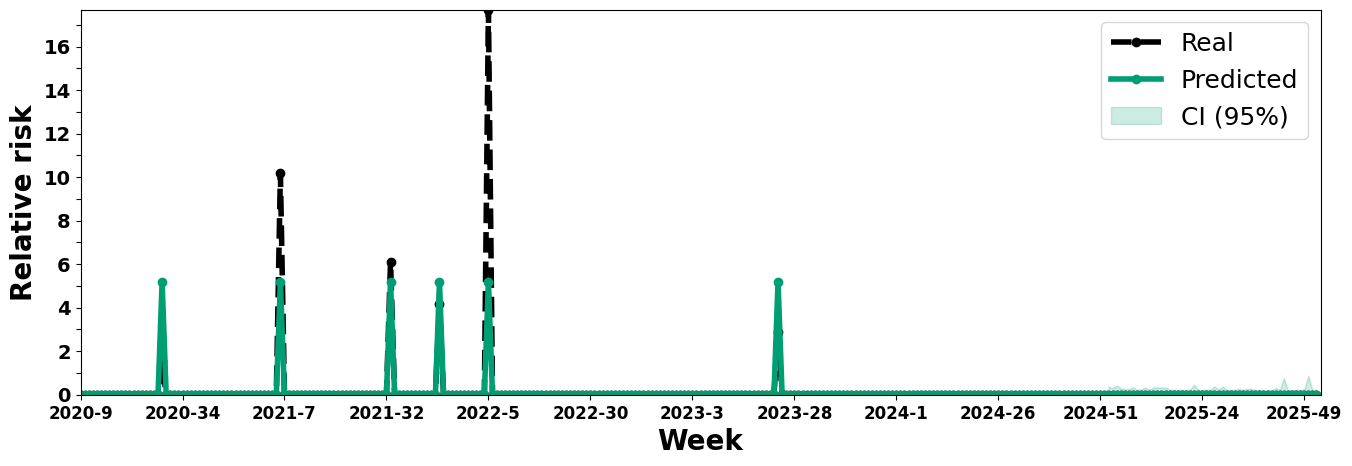

In [8]:
best_1 = Model(df, str(best_cantons[0]))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = best_1.partition()

lower_bound, upper_bound = best_1.prediction_intervals_aci("hrf", X_combined, y_combined, X_test, y_test, epsilon, alpha=0.05, gamma=0.005, n_resamplings=100, full = True)

best_1.serie_temp_canton("hrf", X_combined, y_combined, y_test, lower_bound, upper_bound, epsilon, lims = [0, max(np.max(np.exp(y_combined) - epsilon), np.max(np.exp(y_test) - epsilon), np.max(upper_bound))], full = True)

Elapsed time: 92.08 seconds


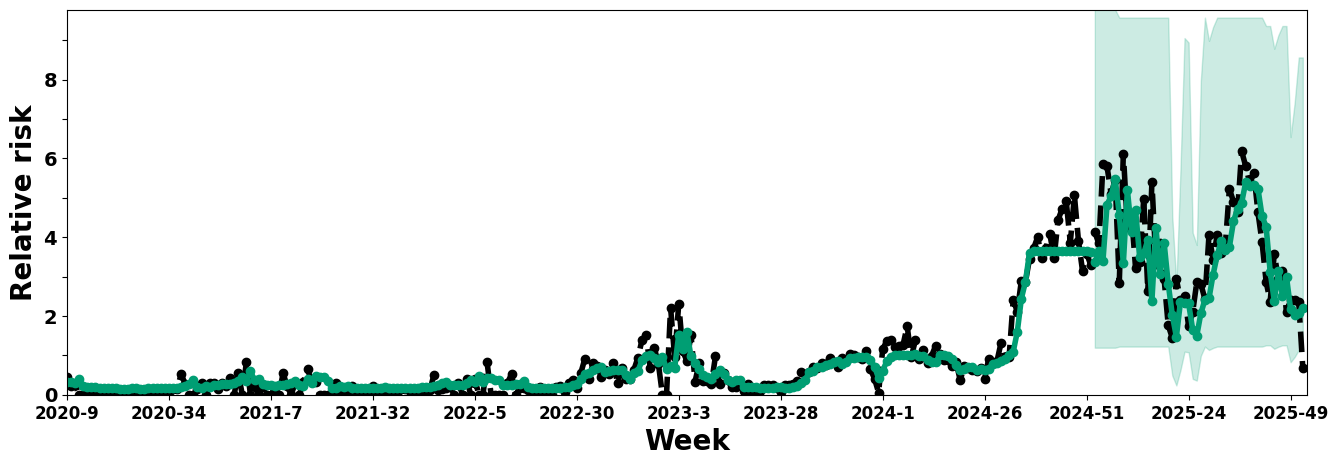

In [9]:
best_2 = Model(df, str(best_cantons[1]))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = best_2.partition()

lower_bound, upper_bound = best_2.prediction_intervals_aci("hrf", X_combined, y_combined, X_test, y_test, epsilon, alpha=0.05, gamma=0.005, n_resamplings=100, full = True)

best_2.serie_temp_canton("hrf", X_combined, y_combined, y_test, lower_bound, upper_bound, epsilon, lims = [0, max(np.max(np.exp(y_combined) - epsilon), np.max(np.exp(y_test) - epsilon), np.max(upper_bound))], full = True)

Elapsed time: 90.56 seconds


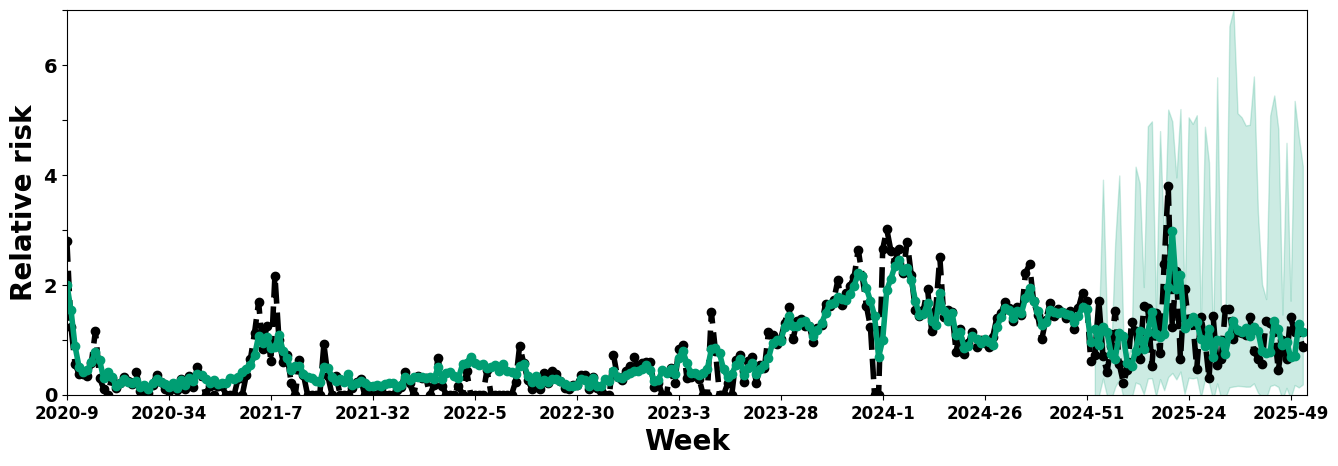

In [10]:
best_3 = Model(df, str(best_cantons[2]))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = best_3.partition()

lower_bound, upper_bound = best_3.prediction_intervals_aci("hrf", X_combined, y_combined, X_test, y_test, epsilon, alpha=0.05, gamma=0.005, n_resamplings=100, full = True)

best_3.serie_temp_canton("hrf", X_combined, y_combined, y_test, lower_bound, upper_bound, epsilon, lims = [0, max(np.max(np.exp(y_combined) - epsilon), np.max(np.exp(y_test) - epsilon), np.max(upper_bound))], full = True)

Elapsed time: 35.96 seconds


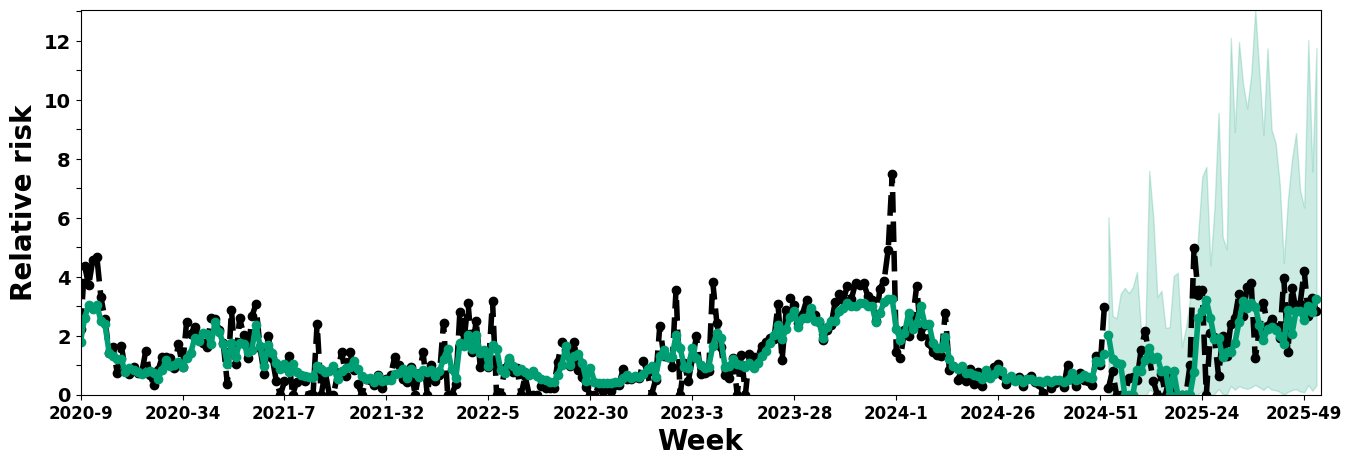

In [11]:
best_4 = Model(df, str(best_cantons[3]))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = best_4.partition()

lower_bound, upper_bound = best_4.prediction_intervals_aci("hxgb", X_combined, y_combined, X_test, y_test, epsilon, alpha=0.05, gamma=0.005, n_resamplings=100, full = True)

best_4.serie_temp_canton("hxgb", X_combined, y_combined, y_test, lower_bound, upper_bound, epsilon, lims = [0, max(np.max(np.exp(y_combined) - epsilon), np.max(np.exp(y_test) - epsilon), np.max(upper_bound))], full = True)

# <a id='toc3_'></a>[Worst-performing municipalities](#toc0_)

In [7]:
worst_cantons = df_nrmse.nlargest(4, "lowest_nrmse").iloc[:, 0].tolist()
worst_cantons

[116, 204, 211, 306]

In [8]:
df_nrmse

,canton,nrmse_rf,mean_rf,lower_rf,upper_rf,nrmse_xgb,mean_xgb,lower_xgb,upper_xgb,nrmse_hrf,...,upper_hrf,nrmse_hxgb,mean_hxgb,lower_hxgb,upper_hxgb,best_nrmse_model,best_mean_model,best_lower_model,best_upper_model,lowest_nrmse
0,101,0.330563,0.329503,0.260636,0.402450,0.348908,0.346972,0.294245,0.398357,0.275804,...,0.328865,0.301547,0.299223,0.238515,0.356827,nrmse_hrf,mean_hrf,lower_hrf,upper_hrf,0.275804
1,102,1.162495,1.151686,0.951745,1.319656,1.138141,1.131237,0.952410,1.285742,1.281000,...,1.642297,1.243749,1.245068,0.980185,1.531365,nrmse_xgb,mean_xgb,lower_rf,upper_xgb,1.138141
2,103,0.727550,0.713189,0.553415,0.867016,0.733218,0.719769,0.560442,0.861503,0.717977,...,0.911597,0.708387,0.707112,0.564788,0.884836,nrmse_hxgb,mean_hxgb,lower_rf,upper_xgb,0.708387
3,104,1.599182,1.582620,1.368483,1.848644,1.604487,1.585048,1.364691,1.817340,2.187357,...,3.186964,2.079355,2.121954,1.645601,2.860212,nrmse_rf,mean_rf,lower_xgb,upper_xgb,1.599182
4,105,2.230510,2.095969,1.044624,2.350112,2.230239,2.025678,0.417229,2.373252,2.705636,...,4.339687,2.636009,2.521311,1.017324,3.884538,nrmse_xgb,mean_xgb,lower_xgb,upper_rf,2.230239
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,702,0.830942,0.817404,0.682160,0.960381,0.832133,0.823851,0.692888,0.967114,1.017273,...,1.390199,0.988234,0.987768,0.745699,1.276161,nrmse_rf,mean_rf,lower_rf,upper_rf,0.830942
78,703,0.758357,0.757283,0.601956,0.949565,0.770505,0.765225,0.600200,0.955178,1.160532,...,1.660042,1.012889,1.013135,0.726910,1.389744,nrmse_rf,mean_rf,lower_xgb,upper_rf,0.758357
79,704,1.123944,1.119810,0.945690,1.336214,1.113208,1.107995,0.940960,1.299329,1.141601,...,1.544978,1.226068,1.232444,0.932784,1.561040,nrmse_xgb,mean_xgb,lower_hrf,upper_xgb,1.113208
80,705,1.319359,1.302704,1.073079,1.527037,1.313240,1.296842,1.061752,1.548839,1.581424,...,2.203816,1.880275,1.902213,1.374443,2.661553,nrmse_xgb,mean_xgb,lower_xgb,upper_rf,1.313240


Elapsed time: 11.95 seconds


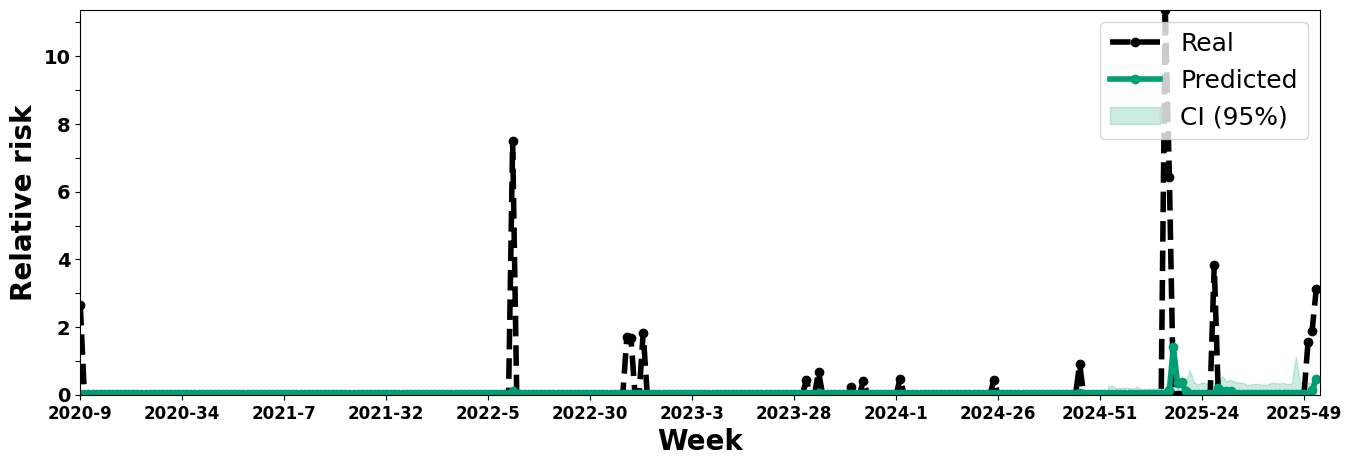

In [14]:
worst_1 = Model(df, str(worst_cantons[3]))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = worst_1.partition()

lower_bound, upper_bound = worst_1.prediction_intervals_aci("xgb", X_combined, y_combined, X_test, y_test, epsilon, alpha=0.05, gamma=0.005, n_resamplings=100)

worst_1.serie_temp_canton("xgb", X_combined, y_combined, y_test, lower_bound, upper_bound, epsilon, lims = [0, max(np.max(np.exp(y_combined) - epsilon), np.max(np.exp(y_test) - epsilon), np.max(upper_bound))])

Elapsed time: 149.18 seconds


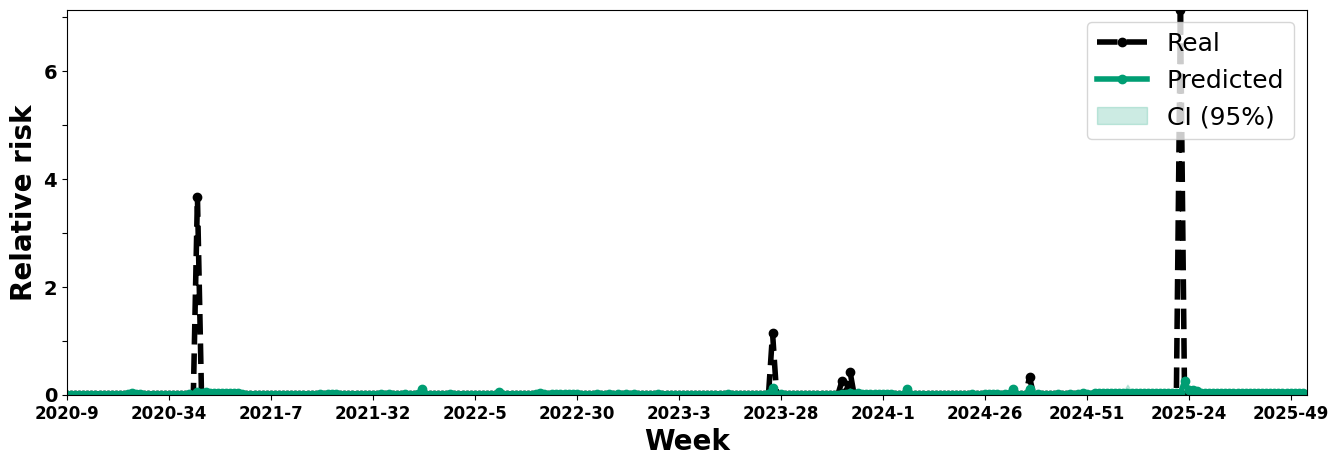

In [11]:
worst_2 = Model(df, str(worst_cantons[2]))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = worst_2.partition()

lower_bound, upper_bound = worst_2.prediction_intervals_aci("rf", X_combined, y_combined, X_test, y_test, epsilon, alpha=0.05, gamma=0.005, n_resamplings=100)

worst_2.serie_temp_canton("rf", X_combined, y_combined, y_test, lower_bound, upper_bound, epsilon, lims = [0, max(np.max(np.exp(y_combined) - epsilon), np.max(np.exp(y_test) - epsilon), np.max(upper_bound))])

Elapsed time: 11.71 seconds


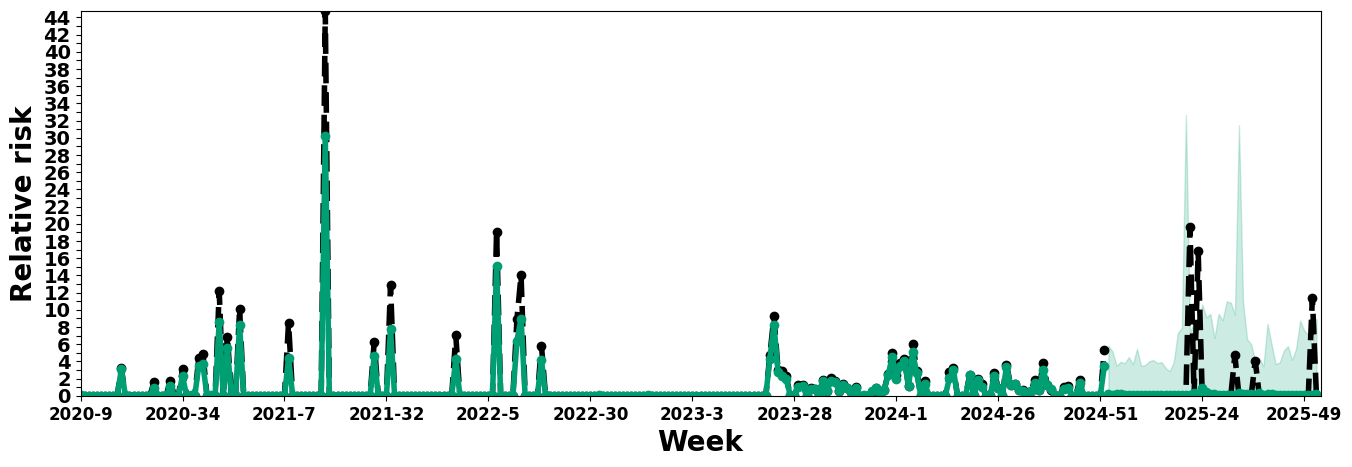

In [ ]:
worst_3 = Model(df, str(worst_cantons[1]))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = worst_3.partition()

lower_bound, upper_bound = worst_3.prediction_intervals_aci("xgb", X_combined, y_combined, X_test, y_test, epsilon, alpha=0.05, gamma=0.005, n_resamplings=100)

worst_3.serie_temp_canton("xgb", X_combined, y_combined, y_test, lower_bound, upper_bound, epsilon, lims = [0, max(np.max(np.exp(y_combined) - epsilon), np.max(np.exp(y_test) - epsilon), np.max(upper_bound))], full = True)

Elapsed time: 43.96 seconds


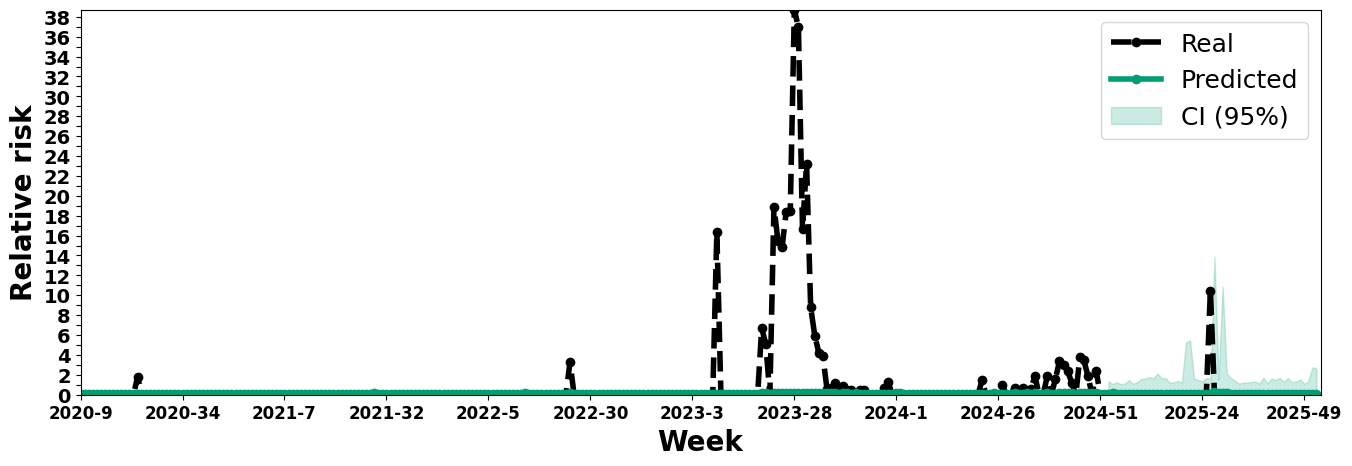

In [12]:
worst_4 = Model(df, str(worst_cantons[0]))

X_combined, y_combined, X_train, X_test, y_test, test, pds, epsilon = worst_4.partition()

lower_bound, upper_bound = worst_4.prediction_intervals_aci("xgb", X_combined, y_combined, X_test, y_test, epsilon, alpha=0.05, gamma=0.005, n_resamplings=100)

worst_4.serie_temp_canton("xgb", X_combined, y_combined, y_test, lower_bound, upper_bound, epsilon, lims = [0, max(np.max(np.exp(y_combined) - epsilon), np.max(np.exp(y_test) - epsilon), np.max(upper_bound))])